In [1]:
import pandas as pd
import ast

In [8]:
signatures = pd.read_csv('/home/lnemati/pathway_crosstalk/data/immunotherapy/tiger_signatures/all_signatures.csv', index_col=0)

In [9]:
signatures['genes'] = signatures['genes'].apply(ast.literal_eval)

In [10]:
signatures.loc['TLS', 'genes']

['BCL6', 'CCL19', 'CCL21', 'CCR7', 'CD86', 'CXCL13', 'CXCR4', 'LAMP3', 'SELL']

In [11]:
signatures

,genes
signature,
T cell-inflamed GEP,"[CCL5, CD27, CD274, CD276, CD8A, CMKLR1, CXCL9..."
TAM M2,"[A1BG, A1CF, A2M, A2ML1, A3GALT2, A4GALT, A4GN..."
MDSC,"[A1BG, A1CF, A2M, A2ML1, A4GALT, A4GNT, AAA1, ..."
CD8,"[CD8A, CD8B]"
TLS,"[BCL6, CCL19, CCL21, CCR7, CD86, CXCL13, CXCR4..."
T cell exclusion,"[A1BG, A1BG-AS1, A1CF, A2M, A2M-AS1, A2ML1, A2..."
TLS-melanoma,"[CCR6, CD1D, CD79B, CETP, EIF1AY, LAT, PTGDS, ..."
T cell Dysfunction,"[A2M, A2ML1, A4GALT, A4GNT, AAAS, AACS, AADAC,..."
CAF,"[A1BG, A1BG-AS1, A1CF, A2M, A2M-AS1, A2ML1, A2..."


In [31]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
from scipy.stats import ks_2samp
from scipy.stats import mannwhitneyu
from scipy.stats import false_discovery_control
import re
import seaborn as sns

In [32]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

In [27]:
ccc = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc.csv', index_col=0)
ia1 = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/intact_direct.csv', index_col=0)
ia2 = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/intact_physical.csv', index_col=0)
ia3 = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/intact_association.csv', index_col=0)


In [28]:
ccc['type'] = 'CCI'
ia1['type'] = ia1['type'].replace({'non-enzymatic direct': 'IA Direct', 'enzymatic direct': 'IA Direct'})
ia2['type'] = ia2['type'].replace({'physical': 'IA Physical'})
ia3['type'] = ia3['type'].replace({'association': 'IA Association'})


In [29]:
df = pd.concat([ccc, ia1, ia2, ia3]).drop_duplicates()
df.to_csv('/home/lnemati/pathway_crosstalk/data/interactions/all_ccis_and_intact.csv')

In [30]:
df.type.value_counts()

type
IA Association    302042
IA Physical       111267
IA Direct           7852
CCI                 3991
Name: count, dtype: int64

# 2_GPCRS

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import os
import numpy as np
import scanpy as sc
import PyWGCNA
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import mannwhitneyu, false_discovery_control
import re
from itertools import combinations
from scipy.stats import pearsonr, ks_2samp
import ast
from PIL import Image
import os
from adjustText import adjust_text

In [54]:
def stack_triangle(df, col):
    df = pd.DataFrame(
        df.where(
            np.tri(
                df.shape[0],
                dtype=bool,
                k=-1
            ),
            np.nan
        ).stack(dropna=True), columns=[col] 
    )
    
    return df


In [55]:
# Function that generates and saves the ROC curve
def generate_roc_curve(
    data,
    target_col,
    feature_col,
):
    # ROC curve using all gene pairs
    fpr, tpr, thr = roc_curve(data[target_col], data[feature_col])
    auroc = roc_auc_score(data[target_col], data[feature_col])
    
    return fpr, tpr, thr, auroc

In [56]:
def fig_to_panels(fig, axes, output_dir):
    # Save individual panels of a figure 
    
    for panel_name, ax in axes.items():
        # Extract the panel title
        panel_title = ax.get_title()

        # Sanitize the panel title to use in filenames
        safe_title = panel_title.replace(" ", "_").replace("/", "_").replace("\n", "_").lower()

        # Create the filename for the current panel
        output_file = os.path.join(output_dir,safe_title)

        # Adjust the bounding box to include everything (labels, titles, etc.)
        extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

        # Save the individual panel using the adjusted bounding box
        fig.savefig(output_file + '.pdf', bbox_inches=extent, dpi=300)
        fig.savefig(output_file + '.png', bbox_inches=extent)

        print(f"Saved panel '{panel_title}' to {output_file}")


In [57]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

In [58]:
def network_to_adj(network_path):
    network = pd.read_csv(
        network_path,
        usecols=['complex1', 'complex2', 'adj']
    )

    # Add a mirrored version of the network to make it symmetric
    network_mirrored = network.copy()
    network_mirrored.columns = ['complex2', 'complex1', 'adj']
    network = pd.concat([network, network_mirrored], ignore_index=True)

    adj = network.pivot(index='complex1', columns='complex2', values='adj').fillna(0)
    return adj

# GPCRs

In [59]:
# Read GPCRs
gpcrs = pd.read_csv('/home/fraimondi/BIOINFO1_BK/francesco/GPCR/gpcrs_genes.txt')['Symbol'].values

# Read ligands
lr = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv')
lr = lr[lr.receptor.isin(gpcrs)]

# Read G-Proteins coupling
gprots_couplings = pd.read_csv('/home/lnemati/resources/gpcr_couplings/gpcr_couplings.csv')
gprots_couplings = gprots_couplings.query('n_sources >=3')
gprots_couplings = gprots_couplings.query('type != "precogx_only"')
gprots_couplings.set_index('gpcr', inplace=True, drop=False)
gprots_couplings.index.name = None
gprots_couplings = gprots_couplings.groupby('gpcr')['gprot'].apply(list)
gprots = gprots_couplings.values.sum()


In [60]:
# Get G-Proteins, GPCRs and their ligands
gpcrs_genes = set(gpcrs) | set(gprots) | set(lr.ligand.values) | set(lr.receptor.values)

In [61]:
ncoev = pd.read_csv('/home/lnemati/pathway_crosstalk/results/gpcrs/normal_jaccard_coevolution.csv', index_col=0)

df = pd.DataFrame(columns=['gpcr', 'interactor', 'interactor_type', 'condition', 'value'])

for gpcr in gprots_couplings.index.intersection(ncoev.index):
    couplings = ncoev.index.intersection(gprots_couplings.loc[gpcr])
    values = ncoev.loc[gpcr, couplings].to_frame(name = 'value')
    values['gpcr'] = gpcr
    values['interactor'] = values.index
    values['interactor_type'] = 'G-Protein'
    values['tissue'] = 'Coevolution'
    values['condition'] = 'Coevolution'
    values['value_type'] = 'jaccard'

    df = pd.concat([df, values])
    
for gpcr in ncoev.index.intersection(lr.receptor.unique()):
    ligands = ncoev.index.intersection(lr[lr['receptor'] == gpcr].ligand.unique())
    values = ncoev.loc[gpcr, ligands].to_frame(name = 'value')
    values['gpcr'] = gpcr
    values['interactor'] = values.index
    values['interactor_type'] = 'Ligand'
    values['tissue'] = 'Coevolution'
    values['condition'] = 'Coevolution'
    values['value_type'] = 'jaccard'

    df = pd.concat([df, values])

df = df.reset_index(drop=True)

In [62]:
df = pd.concat([df, pd.read_csv('/home/lnemati/pathway_crosstalk/results/gpcrs/all_gpcr_interactions.csv')])
#df = df[df['subtissue'] != 'testis']
df.query('not (subtissue == "testis" and condition == "normal")')
df = df.groupby(['gpcr', 'interactor', 'condition', 'interactor_type', 'tissue', 'value_type'], as_index=False)['value'].mean()
df = df.query('value_type in ["correlation", "jaccard"]')
df['condition'] =df['condition'].replace({'normal': 'Normal Co-Expression', 'tumor': 'Tumor Co-Expression'})

# Tumor Coevolution - GPCRS

In [63]:
df_complete = pd.read_csv('/projects/bioinformatics/DB/CancerTracer/intra_heterogeneity_data.txt', sep='\t')

# Remove wrongly formatted row
df_complete = df_complete[~df_complete.index.isin(['p075_p3'])]

In [64]:
import re
import pandas as pd

def extract_mutation_info(mutation_string, allowed_strings=None):
    # Return empty lists if the input string is missing or empty
    if pd.isna(mutation_string) or mutation_string == '':
        return [], [], []

    # Split the string into individual entries
    gene_entries = mutation_string.split(',')
    
    if allowed_strings is None:
        filtered_entries = [entry for entry in gene_entries]
    else:
    # Filter entries that have allowed patterns and contain a closing parenthesis
        filtered_entries = [entry for entry in gene_entries if any([x in entry for x in allowed_strings]) and ')' in entry]

    # Initialize lists to store genes, mutations, and samples
    genes = []
    mutations = []
    samples = []

    # Process each filtered entry
    for entry in filtered_entries:
        # Get gene: Keep only the text before the first set of parentheses
        gene = re.sub(r'\s*\(.*$', '', entry).strip()

        # Get mutation: Extract the content inside the parentheses
        mutation_match = re.search(r'\(([^()]*)\)', entry)
        mutation = mutation_match.group(1).strip() if mutation_match else ''

        # Get sample: Keep only the text after the first set of parentheses
        sample_match = re.search(r'\(.*?\)\s*([- ]*)(.*)', entry)
        sample = sample_match.group(2).strip('- ').strip() if sample_match else ''

        # Append the parsed components to respective lists
        genes.append(gene)
        mutations.append(mutation)
        samples.append(sample)

    # Return the lists of genes, mutations, and samples
    return genes, mutations, samples


In [65]:
dfs = []

for col in ['Trunk_mutation', 'Branch_mutation', 'Private_mutation']:
    # Separate individual mutations
    # Use regex to split only on commas that are not inside parentheses
    vals = df_complete[col].str.split(r',\s*(?![^(]*\))', expand=True)
    
    # Find nans
    keep = ~vals.isna()
    
    # Add sample ids
    samples = df_complete['Sample']
    samples.index = samples.values
    vals.index = samples.values
    vals = (vals.T.astype(str) + samples).T
    
    # Remove nans
    vals = vals.values[keep]

    #allowed_strings = ['(p.', '(amp', '(del']
    allowed_strings = ['(p.']
    #allowed_strings = None
    
    genes, mutations, samples = extract_mutation_info(", ".join(vals), allowed_strings = allowed_strings)
    
    #genes     = [get_gene(x)     for x in vals]
    #mutations = [get_mutation(x) for x in vals]
    #samples   = [get_sample(x)   for x in vals]
    
    mutations_df = pd.DataFrame()
    mutations_df.index = genes
    mutations_df['mutation'] = mutations
    mutations_df['patient'] = samples
    mutations_df['when'] = col.strip('_mutation')
    
    dfs.append(mutations_df)
    
mutations_df = pd.concat(dfs)
mutations_df['gene'] = mutations_df.index

mutations_df = mutations_df[~mutations_df.index.isin(['', ' ', '-'])]
mutations_df = mutations_df[~mutations_df['patient'].isin(['', ' ', '-'])]
mutations_df = mutations_df[~mutations_df['gene'].isin(['', ' ', '-'])]

In [66]:
# Read GPCRs
gpcrs = pd.read_csv('/home/fraimondi/BIOINFO1_BK/francesco/GPCR/gpcrs_genes.txt')['Symbol'].values

# Read ligands
lr = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv')
gpcrs_lr = lr[lr.receptor.isin(gpcrs)]
gpcrs_ligands = list(set(gpcrs_lr.ligand))

# Read G-Proteins coupling
gprots_couplings = pd.read_csv('/home/lnemati/resources/gpcr_couplings/gpcr_couplings.csv')
gprots = list(set(gprots_couplings.gprot))

gprots_couplings = gprots_couplings.query('n_sources >= 3')
gprots_couplings = gprots_couplings.query('type != "precogx_only"')
gprots_couplings.set_index('gpcr', inplace=True, drop=False)
gprots_couplings.index.name = None
gprots_couplings = gprots_couplings.groupby('gpcr')['gprot'].apply(list)


In [67]:
ccc_genes = set(lr.receptor).union(lr.ligand)

In [68]:
# Get G-Proteins, GPCRs and their ligands
gpcrs_genes = set(gpcrs) | set(gprots) | set(gpcrs_lr.ligand.values)# | set(gpcrs_lr.receptor.values)

In [69]:
mutations_df['gpcr']   = mutations_df.gene.isin(gpcrs)
mutations_df['gprot']  = mutations_df.gene.isin(gprots)
mutations_df['ligand'] = mutations_df.gene.isin(gpcrs_ligands)

In [70]:
mutations_df.index = (mutations_df['patient'] + '_' + mutations_df['gene'])
mutations_df['unique_id'] = (mutations_df['patient'] + '_' + mutations_df['gene'])

In [71]:
counts = mutations_df.groupby(['unique_id', 'when']).size().reset_index(name='count')
counts = counts.sort_values(by='count', ascending=False)
counts['patient'] = counts['unique_id'].str.split('_').apply(lambda x: '_'.join(x[:-1]))
counts['gene'] = counts['unique_id'].str.split('_').apply(lambda x: '_'.join(x[-1:]))

counts['ccc'] = False
counts.loc[counts.gene.isin(ccc_genes), 'ccc'] = True

In [72]:
genes = counts.groupby(['gene', 'when'])['count'].sum().to_frame()

In [73]:
genes['gene'] = genes.index.get_level_values(0)
genes['when'] = genes.index.get_level_values(1)
genes.index = range(len(genes))

In [74]:
# Group by 'gene' and calculate the total counts for each gene
total_counts = genes.groupby('gene')['count'].sum()

# Sort genes by total count in descending order
genes = genes.set_index('gene').loc[total_counts.sort_values(ascending=False).index].reset_index()

In [75]:
## Init dataframe for test results
results = pd.DataFrame(columns=['auroc', 'pval'])

genes_pivot = genes.pivot(index='gene', columns='when', values='count').fillna(0)
genes_pivot = genes_pivot.loc[total_counts.sort_values(ascending=False).index]

# All genes
genes_pivot_all = genes_pivot
total_all_log10 = np.log10(genes_pivot_all.sum(axis=1))
total_lig_log10 = total_all_log10.loc[total_all_log10.index.isin(gpcrs_ligands)]
total_gprot_log10 = total_all_log10.loc[total_all_log10.index.isin(gprots)]
total_gpcr_log10 = total_all_log10.loc[total_all_log10.index.isin(gpcrs)]

# Log10 Total comparisons
for label, subset, drop_ids in [
    ('ligand vs all', total_lig_log10, gpcrs_ligands),
    ('gprot vs all', total_gprot_log10, gprots),
    ('gpcr vs all', total_gpcr_log10, gpcrs)
]:
    others = total_all_log10.drop(drop_ids, errors='ignore')
    result = mannwhitneyu(subset, others)
    auroc = result.statistic / (len(subset) * len(others))
    results.loc[label, 'auroc'] = auroc
    results.loc[label, 'pval'] = result.pvalue
    results.loc[label, 'tested_quantity'] = 'Log10 Total'

# Apply multiple testing correction
results['pval_adj'] = false_discovery_control(results.pval.astype(float).values)


In [76]:
from itertools import combinations
import numpy as np
import pandas as pd

def compute_jaccards(sub_df):
    # Get unique patients per gene, filtered to GPCR genes
    patients_per_gene = (
        sub_df.groupby('gene')['patient']
        .unique()
        .loc[lambda x: x.index.isin(gpcrs_genes)]
    )
    genes = patients_per_gene.index

    # Initialize Jaccard matrix
    jaccard_matrix = pd.DataFrame(
        np.eye(len(genes)), index=genes, columns=genes
    )

    for g1, g2 in combinations(genes, 2):
        set1, set2 = set(patients_per_gene[g1]), set(patients_per_gene[g2])
        union = set1 | set2
        sim = len(set1 & set2) / len(union) if union else 0
        jaccard_matrix.at[g1, g2] = sim
        jaccard_matrix.at[g2, g1] = sim

    # Flatten matrix
    jaccard = jaccard_matrix.stack()

    # Ligand-receptor Jaccard values
    lr_pairs = gpcrs_lr.set_index(['ligand', 'receptor']).index
    jaccard_lr = jaccard.loc[lr_pairs.intersection(jaccard.index)]

    # G-protein Jaccard values
    jaccard_gprot = []

    for gpcr in gprots_couplings.index.intersection(jaccard_matrix.index):
        interactors = jaccard_matrix.index.intersection(gprots_couplings.loc[gpcr])
        values = jaccard_matrix.loc[gpcr, interactors].reset_index()
        values.columns = ['interactor', 'value']
        values['gpcr'] = gpcr
        jaccard_gprot.append(values)

    jaccard_gprot = (
        pd.concat(jaccard_gprot)
        .set_index(['gpcr', 'interactor'])['value']
    )

    return jaccard_lr, jaccard_gprot

jaccard_lr_trunk, jaccard_gprot_trunk = compute_jaccards(mutations_df[mutations_df['when'].isin(['Trunk'])])
jaccard_lr_branch, jaccard_gprot_branch = compute_jaccards(mutations_df[mutations_df['when'].isin(['Trunk', 'Branch'])])
jaccard_lr_private, jaccard_gprot_private = compute_jaccards(mutations_df)

In [77]:
# Combine Jaccard data into a long-format DataFrame
all_data = []

# Add data from the 'Trunk' condition
for score in jaccard_lr_trunk:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Trunk'})
for score in jaccard_gprot_trunk:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Trunk'})

# Add data from the 'Branch' condition
for score in jaccard_lr_branch:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Branch'})
for score in jaccard_gprot_branch:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Branch'})

# Add data from the 'Private' condition
for score in jaccard_lr_private:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Private'})
for score in jaccard_gprot_private:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Private'})

# Convert the combined data into a DataFrame
df_jaccard = pd.DataFrame(all_data)

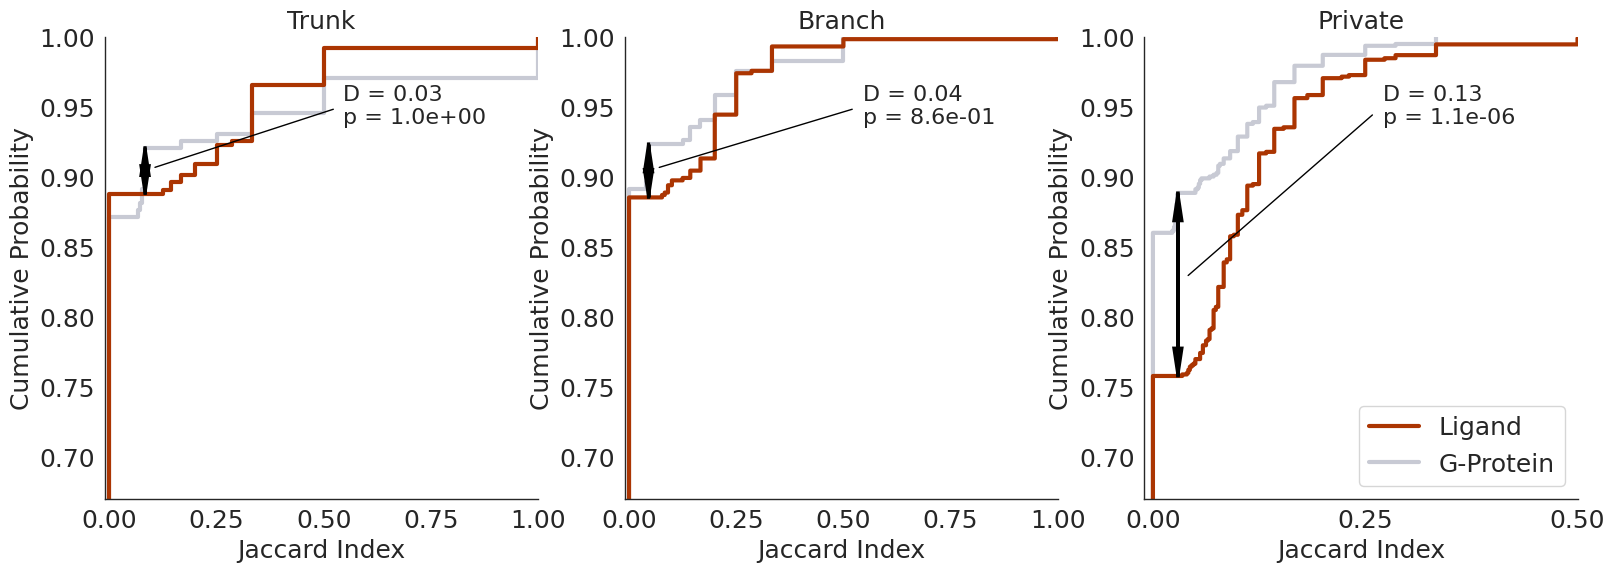

In [78]:
def plot_cdf_with_ks(data, condition, ax, color_ligand, color_gpcr):
    fs = 18

    # Set ylim and xlim based on condition
    ax.set_ylim(0.67, 1.)
    
    if condition == "Private":
        ax.set_xlim(-0.01, 0.5)
        arrow_width = 0.01  # half width
        ax.set_xticks([0, 0.25, 0.5])

    else:
        ax.set_xlim(-0.01, 1)
        arrow_width = 0.02  # default width
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1.00])

    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']
    
    # KS test
    ks_stat, p_value = ks_2samp(ligand_values, gpcr_values)

    # ECDF plots
    sns.ecdfplot(ligand_values, ax=ax, color=color_ligand, label='Ligand', linewidth=3, zorder=2)
    sns.ecdfplot(gpcr_values, ax=ax, color=color_gpcr, label='G-Protein', linewidth=3, zorder=1)

    # D-statistic logic
    cdf_ligand = np.sort(ligand_values)
    cdf_gpcr = np.sort(gpcr_values)
    all_values = np.sort(np.unique(np.concatenate((cdf_ligand, cdf_gpcr))))
    cdf_ligand_y = np.searchsorted(cdf_ligand, all_values, side='right') / len(cdf_ligand)
    cdf_gpcr_y = np.searchsorted(cdf_gpcr, all_values, side='right') / len(cdf_gpcr)
    max_diff_index = np.argmax(np.abs(cdf_ligand_y - cdf_gpcr_y))

    x_max_diff = all_values[max_diff_index]
    y1_max_diff = cdf_ligand_y[max_diff_index]
    y2_max_diff = cdf_gpcr_y[max_diff_index]
    midpoint_y = (y1_max_diff + y2_max_diff) / 2

    # Vertical D-statistic line and arrows
    ax.vlines(x_max_diff, y1_max_diff, y2_max_diff, color='k', linestyle='-', lw=2)
    ax.arrow(x_max_diff, y1_max_diff, 0, y2_max_diff - y1_max_diff, 
             color='k', linestyle='-', lw=2, head_width=arrow_width, head_length=0.02, length_includes_head=True, zorder=10)
    ax.arrow(x_max_diff, y2_max_diff, 0, y1_max_diff - y2_max_diff, 
             color='k', linestyle='-', lw=2, head_width=arrow_width, head_length=0.02, length_includes_head=True, zorder=10)

    # Annotation with KS stat
    text_object = ax.text(
        0.55, 0.85,
        f'D = {ks_stat:.2f}\np = {p_value:.1e}',
        fontsize=fs - 2, ha='left', va='center',
        transform=ax.transAxes,
    )

    text_x, text_y = text_object.get_position()
    max_diff_axis_rel = ax.transData.transform((x_max_diff, midpoint_y))
    max_diff_axis_rel_x, max_diff_axis_rel_y = ax.transAxes.inverted().transform(max_diff_axis_rel)

    direction_x = max_diff_axis_rel_x - text_x
    direction_y = max_diff_axis_rel_y - text_y

    offset_x = direction_x * 0.95
    offset_y = direction_y * 0.95

    start_x = text_x + offset_x
    start_y = text_y + offset_y
    end_x = max_diff_axis_rel_x - offset_x
    end_y = max_diff_axis_rel_y - offset_y

    ax.plot([start_x, end_x], [start_y, end_y], color='k', lw=1, linestyle='-', zorder=9, transform=ax.transAxes)

    # Axis labels and legend
    ax.set_title(f'{condition}', fontsize=fs)
    ax.set_xlabel('Jaccard Index', fontsize=fs)
    ax.set_ylabel('Cumulative Probability', fontsize=fs)
    ax.tick_params(labelsize=fs)
    ax.legend(fontsize=fs, loc='lower right')
    ax.grid(False)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Create a subplot mosaic with 1x3 grid layout
fig = plt.figure(figsize=(19, 6))

# Create the axes using the subplot mosaic
axes = fig.subplot_mosaic(
    """
    ABC
    """
)

# Plot for each condition
for i, condition in enumerate(df_jaccard['condition'].unique()):
    plot_cdf_with_ks(df_jaccard, condition, axes[chr(65 + i)], tcolor, lightgray)

# Remove legends from the first two axes
for ax in axes['A'], axes['B']:
    ax.legend_.remove()

# Save the figure
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/gpcrs/gpcrs_tumor_coevolution.png', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/gpcrs/gpcrs_tumor_coevolution.pdf', bbox_inches='tight', dpi=300)

# Show the plot
plt.show()

In [79]:
# Function to run the KS test and return the KS statistic and p-value
def get_pvals_stats(data, condition):
    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']

    # Perform KS test
    ks_stat, p_value = ks_2samp(ligand_values, gpcr_values)
    
    return ks_stat, p_value


In [87]:

def plot_cdf_with_ks(
    data,
    condition,
    ax,
    ks_stat,
    adjusted_p_value,
    color_ligand,
    color_gpcr, 
    ylim=None,
    xlim=None,    
    text_coords=(0.35, 0.85),
    text_ha='right',
):
    # Optionally set limits before plotting
    if ylim:
        ax.set_ylim(ylim)
    if xlim:
        ax.set_xlim(xlim)
        
    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']

    # Plot the ECDFs
    sns.ecdfplot(gpcr_values, ax=ax, color=color_gpcr, label='G-Protein', linewidth=3, zorder=1)
    sns.ecdfplot(ligand_values, ax=ax, color=color_ligand, label='Ligand', linewidth=3, zorder=2)

    # Highlight the maximum difference (D-statistic)
    cdf_ligand = np.sort(ligand_values)
    cdf_gpcr = np.sort(gpcr_values)
    all_values = np.sort(np.unique(np.concatenate((cdf_ligand, cdf_gpcr))))
    cdf_ligand_y = np.searchsorted(cdf_ligand, all_values, side='right') / len(cdf_ligand)
    cdf_gpcr_y = np.searchsorted(cdf_gpcr, all_values, side='right') / len(cdf_gpcr)
    max_diff_index = np.argmax(np.abs(cdf_ligand_y - cdf_gpcr_y))

    x_max_diff = all_values[max_diff_index]
    y1_max_diff = cdf_ligand_y[max_diff_index]
    y2_max_diff = cdf_gpcr_y[max_diff_index]
    midpoint_y = (y1_max_diff + y2_max_diff) / 2

    head_width  = 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])
    head_length = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])

    # D-statistic lines and arrows
    ax.vlines(x_max_diff, y1_max_diff, y2_max_diff, color='k', linestyle='-', lw=2)
    ax.arrow(x_max_diff, y1_max_diff, 0, y2_max_diff - y1_max_diff, 
             color='k', lw=2, head_width=head_width, head_length=head_length, length_includes_head=True, zorder=10)
    ax.arrow(x_max_diff, y2_max_diff, 0, y1_max_diff - y2_max_diff, 
             color='k', lw=2, head_width=head_width, head_length=head_length, length_includes_head=True, zorder=10)

    # Determine significance marker for p-value
    if adjusted_p_value < 0.001:
        significance = '***'
    elif adjusted_p_value < 0.01:
        significance = '**'
    elif adjusted_p_value < 0.05:
        significance = '*'
    else:
        significance = ''  # Not significant

    # D-statistic annotation with configurable position and alignment
    text_x, text_y = text_coords
    ax.text(
        text_x, text_y,
        f'D = {ks_stat:.2f}\np = {adjusted_p_value:.2e}\n{significance}',
        fontsize=fs, ha=text_ha, va='center',
        transform=ax.transAxes,
    )

    # Draw connector line to D-stat
    max_diff_axis_rel = ax.transData.transform((x_max_diff, midpoint_y))
    max_diff_axis_rel_x, max_diff_axis_rel_y = ax.transAxes.inverted().transform(max_diff_axis_rel)
    direction_x = max_diff_axis_rel_x - text_x
    direction_y = max_diff_axis_rel_y - text_y
    offset_x = direction_x * 0.85
    offset_y = direction_y * 0.85
    start_x = text_x + offset_x
    start_y = text_y + offset_y
    end_x = max_diff_axis_rel_x - offset_x
    end_y = max_diff_axis_rel_y - offset_y
    ax.plot([start_x, end_x], [start_y, end_y], color='k', lw=1, linestyle='-', zorder=9, transform=ax.transAxes)

    # Axes formatting
    ax.set_title(f'{condition}', fontsize=fs)
    ax.set_xlabel('Value', fontsize=fs)
    ax.set_ylabel('Cumulative Probability', fontsize=fs)
    ax.tick_params(labelsize=fs, direction='out')
    ax.legend(fontsize=fs, loc='lower right')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(bottom=True, left=True)  # Ensure ticks are visible
    ax.spines[['right', 'top']].set_visible(False)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    # Set ticks at a specific distance (e.g., 0.5 units)
    tick_distance = 0.5

    # Get the current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create tick positions based on the tick distance, starting from the lowest value within the limits
    x_ticks = np.arange(np.floor(xlim[0] / tick_distance) * tick_distance, 
                        np.ceil(xlim[1] / tick_distance) * tick_distance + tick_distance, 
                        tick_distance)
    y_ticks = np.arange(np.floor(ylim[0] / tick_distance) * tick_distance, 
                        np.ceil(ylim[1] / tick_distance) * tick_distance + tick_distance, 
                        tick_distance)

    # Filter ticks to ensure they are within the current axis limits
    x_ticks = x_ticks[(x_ticks >= xlim[0]) & (x_ticks <= xlim[1])]
    y_ticks = y_ticks[(y_ticks >= ylim[0]) & (y_ticks <= ylim[1])]

    # Apply the calculated ticks
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)



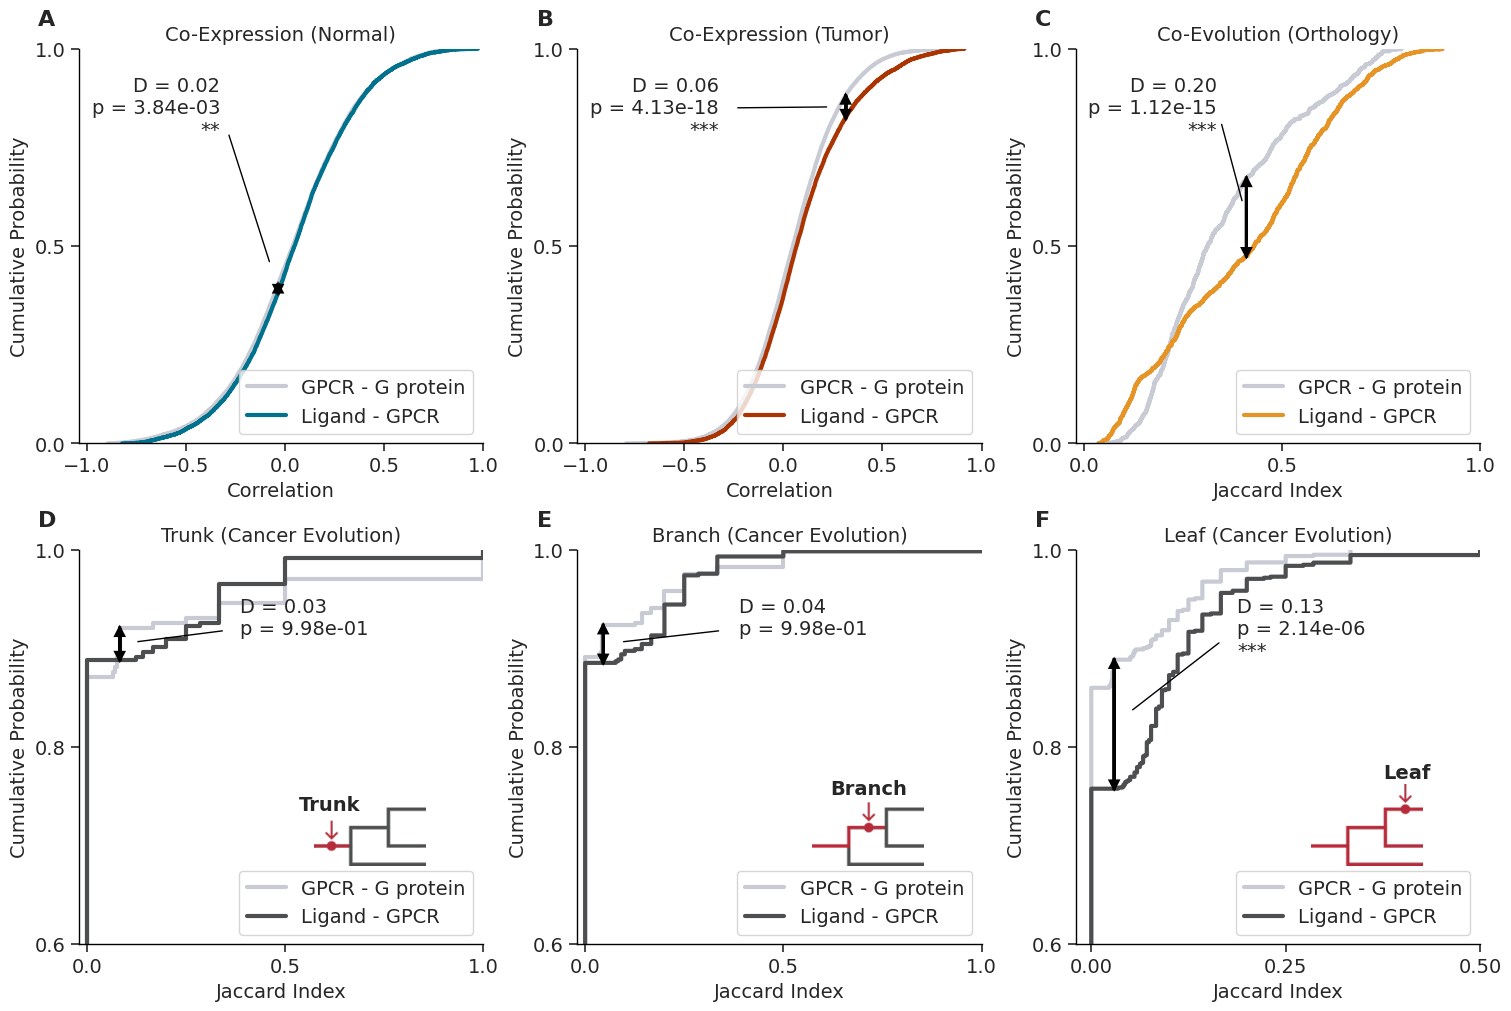

In [88]:
from scipy.stats import ks_2samp
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

fs = 14

# Create figure
fig, axes = plt.subplot_mosaic(
    mosaic="""
    ABC
    DEF
    """,
    figsize=(15, 10),
    constrained_layout=True
)

# Separate the conditions for df and df_jaccard
co_expression_conditions = ['Normal Co-Expression', 'Tumor Co-Expression', 'Coevolution']
jaccard_conditions = ['Trunk', 'Branch', 'Private']

ks_stats = []
p_vals = []

# Run KS test for co-expression conditions using df
for condition in co_expression_conditions:
    ks_stat, p_value = get_pvals_stats(df, condition)  # df for co-expression
    ks_stats.append(ks_stat)
    p_vals.append(p_value)

# Run KS test for Jaccard conditions using df_jaccard
for condition in jaccard_conditions:
    ks_stat, p_value = get_pvals_stats(df_jaccard, condition)  # df_jaccard for Jaccard indices
    ks_stats.append(ks_stat)
    p_vals.append(p_value)

# Apply FDR correction using false_discovery_control
corrected_pvals = false_discovery_control(p_vals)

# Co-expression plots — use defaults
plot_cdf_with_ks(df, 'Normal Co-Expression', axes['A'], ks_stats[0], corrected_pvals[0], ncolor, lightgray, xlim=(-1.04, 1))
plot_cdf_with_ks(df, 'Tumor Co-Expression', axes['B'], ks_stats[1], corrected_pvals[1], tcolor, lightgray, xlim=(-1.04, 1))
#plot_cdf_with_ks(df, 'Coevolution', axes['C'], ks_stats[2], corrected_pvals[2], orangecolor, lightgray, xlim=(-0.02, 1))
plot_cdf_with_ks(df, 'Coevolution', axes['C'], ks_stats[2], corrected_pvals[2], orangecolor, lightgray, xlim=(-0.02, 1))

# Jaccard plots — customize position and alignment
ylim_jaccard = (0.6, 1)
plot_cdf_with_ks(df_jaccard, 'Trunk'  , axes['D'], ks_stats[3], corrected_pvals[3], graycolor, lightgray, ylim=ylim_jaccard, xlim=(-0.02, 1), text_coords=(0.4, 0.8), text_ha='left')
plot_cdf_with_ks(df_jaccard, 'Branch' , axes['E'], ks_stats[4], corrected_pvals[4], graycolor, lightgray, ylim=ylim_jaccard, xlim=(-0.02, 1), text_coords=(0.4, 0.8), text_ha='left')
plot_cdf_with_ks(df_jaccard, 'Private', axes['F'], ks_stats[5], corrected_pvals[5], graycolor, lightgray, ylim=ylim_jaccard, xlim=(-0.02, 0.5), text_coords=(0.4, 0.8), text_ha='left')

# X-axis labels
axes['A'].set_xlabel('Correlation')
axes['B'].set_xlabel('Correlation')
axes['C'].set_xlabel('Jaccard Index')
axes['D'].set_xlabel('Jaccard Index')
axes['E'].set_xlabel('Jaccard Index')
axes['F'].set_xlabel('Jaccard Index')

# Titles
axes['A'].set_title('Co-Expression (Normal)', fontsize=fs)
axes['B'].set_title('Co-Expression (Tumor)', fontsize=fs)
axes['C'].set_title('Co-Evolution (Orthology)', fontsize=fs)
axes['D'].set_title('Trunk (Cancer Evolution)', fontsize=fs)
axes['E'].set_title('Branch (Cancer Evolution)', fontsize=fs)
axes['F'].set_title('Leaf (Cancer Evolution)', fontsize=fs)

axes['D'].set_xticks([0, 0.5, 1])
axes['E'].set_xticks([0, 0.5, 1])
axes['F'].set_xticks([0, 0.25, 0.5])

axes['D'].set_yticks([0.6, 0.8, 1])
axes['E'].set_yticks([0.6, 0.8, 1])
axes['F'].set_yticks([0.6, 0.8, 1])

icons_path = '/home/lnemati/pathway_crosstalk/data/coev_icons'

# === Icon controls ===
icon_scaling_factor = 0.25  # Adjust size of the icons

# === Add icons to panels D, E, and F ===
icon_files = {
    'D': 'trunk_reverse.png',
    'E': 'branch_reverse.png',
    'F': 'leaf_reverse.png',
}

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

for panel, icon_name in icon_files.items():
    icon_path = os.path.join(icons_path, icon_name)
    if os.path.exists(icon_path):
        # Load and resize icon
        icon = Image.open(icon_path)
        width, height = icon.size
        icon_resized = icon.resize((int(width * icon_scaling_factor), int(height * icon_scaling_factor)))
        icon_array = np.array(icon_resized)

        # Create image box
        imagebox = OffsetImage(icon_array, zoom=0.5, resample=True)

        # Position in axes-relative coordinates (x=0.78, y=0.28 is consistent)
        ab = AnnotationBbox(
            imagebox,
            (0.72, 0.3),           # Position of the icon
            xycoords='axes fraction',
            frameon=False
        )

        axes[panel].add_artist(ab)

        # === Add label text above the icon ===
        label_map = {'D': 'Trunk', 'E': 'Branch', 'F': 'Leaf'}
        offsetx = {'D': -0.1,'E': 0, 'F': 0.1}
        offsety = {'D': -0.04,'E': 0, 'F': 0.04}
        axes[panel].text(
            0.72 + offsetx[panel],
            0.37 + offsety[panel],
            label_map[panel],
            transform=axes[panel].transAxes,
            ha='center',
            va='bottom',
            fontsize=fs,
            fontweight='bold'
        )

for ax in axes.values():
    ax.tick_params(length=6, width=1.2)

# === Add panel letters ===
panel_labels = ['A', 'B', 'C', 'D', 'E', 'F']
for label, ax in zip(panel_labels, axes.values()):
    ax.text(
        -0.1, 1.1,  # Top-left corner in axes coords
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='left'
    )
    

# In the legend replace 'G-Protein' with 'GPCR-Gprotein' and 'Ligand' with 'Ligand-GPCR'
for ax in axes.values():
    handles, labels = ax.get_legend_handles_labels()
    new_labels = []
    for label in labels:
        if label == 'G-Protein':
            new_labels.append('GPCR - G protein')
        elif label == 'Ligand':
            new_labels.append('Ligand - GPCR')
        else:
            new_labels.append(label)
    ax.legend(handles, new_labels, fontsize=fs, loc='lower right')

os.makedirs('/home/lnemati/pathway_crosstalk/results/figures/appeal/fig2', exist_ok=True)
plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/appeal/fig2/fig2.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/appeal/fig2/fig2.svg', bbox_inches='tight', dpi=300)
plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/appeal/fig2/fig2.png', bbox_inches='tight', dpi=300)

plt.show()


In [53]:
fig_to_panels(fig, axes, output_dir='/home/lnemati/pathway_crosstalk/results/figures/appeal/fig2/panels')

Saved panel 'Co-Expression (Normal)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/co-expression_(normal)
Saved panel 'Co-Expression (Tumor)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/co-expression_(tumor)
Saved panel 'Co-Evolution (Orthology)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/co-evolution_(orthology)
Saved panel 'Trunk (Cancer Evolution)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/trunk_(cancer_evolution)
Saved panel 'Branch (Cancer Evolution)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/branch_(cancer_evolution)
Saved panel 'Leaf (Cancer Evolution)' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/panels/leaf_(cancer_evolution)


In [44]:
df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/compare_results.csv', index_col=0)
df = df.drop(columns=['avg_coev_tom_correlation'])
df = df[df.index != 'testis']
#df['interactions_mannwhitneyu_p_adj'] = false_discovery_control(df['interactions_mannwhitneyu_p'], method='bh')

In [45]:
df

,condition,n_modules,n_genes,n_samples,sft_power,avg_module_size,tot_interactions,n_interactions_same_module,interactions_auroc,interactions_mannwhitneyu_U,...,avg_intramodular_degree,var_degree,var_intramodular_degree,powerlaw_alpha,powerlaw_xmin,powerlaw_sigma,avg_path_length,diameter,clustering_global,modularity
name,,,,,,,,,,,,,,,,,,,,,
adipose_subcutaneous,normal,29,13573,305,7.0,468.034483,1625,59,0.574870,8.858242e+10,...,3.388817,104.840315,45.381263,4.577862,33.733228,0.158586,2.506232,7.479193,0.435444,0.382097
adipose_visceral_omentum,normal,5,13683,192,24.0,2736.600000,1731,1073,0.575885,9.551960e+10,...,0.191123,0.754040,0.544853,3.532207,3.475940,0.161777,6.558354,19.875354,0.453677,0.502639
adrenal_gland,normal,14,13582,122,10.0,970.142857,1476,167,0.613669,8.664984e+10,...,3.817065,80.729545,66.319089,2.675050,12.548731,0.042008,3.241403,9.885812,0.497046,0.541901
adrenocortical_cancer,tumor,21,12945,74,4.0,616.428571,1099,136,0.581099,5.442855e+10,...,12.630007,674.481935,440.970538,3.726339,49.312750,0.056493,1.821822,2.931932,0.378710,0.282483
cholangiocarcinoma,tumor,36,13821,34,5.0,383.916667,1494,142,0.646033,9.643258e+10,...,13.576651,858.340978,480.491048,3.483404,55.645474,0.052227,1.900262,2.952766,0.395876,0.326291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
thyroid,normal,30,14032,270,6.0,467.733333,1762,142,0.613294,1.045652e+11,...,5.091922,180.006471,90.503164,3.799745,29.380395,0.073831,2.255101,6.580102,0.400196,0.340237
thyroid_carcinoma,tumor,12,14130,484,9.0,1177.500000,1618,228,0.630616,1.042417e+11,...,5.462955,208.696140,130.245311,7.192335,70.037116,0.466765,3.157865,10.707106,0.558909,0.514808
uterus,normal,9,13646,78,20.0,1516.222222,1601,806,0.571356,8.585227e+10,...,0.205024,0.809424,0.461063,3.016837,2.760077,0.113456,5.110920,16.848618,0.415713,0.518859


In [48]:
ccc = pd.read_csv('/projects/bioinformatics/DB/CellCellCommunication/WithEnzymes/cpdb_cellchat_enz.csv')

In [57]:
len(ccc[ccc['interactor1'] == ccc['interactor2']])

18

In [58]:
ccc

,interaction,num_interactors_a,num_interactors_b,interactor1,interactor2,interactor3,interactor4,interactor5,interactor6,interactor7
0,CDH1_ITGA2+ITGB1,1,2,CDH1,ITGA2,ITGB1,NaN,NaN,NaN,NaN
1,CDH1_ITGAE+ITGB7,1,2,CDH1,ITGAE,ITGB7,NaN,NaN,NaN,NaN
2,CDH1_KLRG1,1,1,CDH1,KLRG1,NaN,NaN,NaN,NaN,NaN
3,CDH2_CDH2,1,1,CDH2,CDH2,NaN,NaN,NaN,NaN,NaN
4,CDH2_FCER2,1,1,CDH2,FCER2,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4002,LAMB2_ITGA1+ITGB1,1,2,LAMB2,ITGA1,ITGB1,NaN,NaN,NaN,NaN
4003,LAMB3_ITGA1+ITGB1,1,2,LAMB3,ITGA1,ITGB1,NaN,NaN,NaN,NaN
4004,LAMC1_ITGA1+ITGB1,1,2,LAMC1,ITGA1,ITGB1,NaN,NaN,NaN,NaN
4005,LAMC2_ITGA1+ITGB1,1,2,LAMC2,ITGA1,ITGB1,NaN,NaN,NaN,NaN


In [53]:
ccc[ccc['interactor1'] != ccc['interactor2']]

,interaction,num_interactors_a,num_interactors_b,interactor1,interactor2,interactor3,interactor4,interactor5,interactor6,interactor7
0,CDH1_ITGA2+ITGB1,1,2,CDH1,ITGA2,ITGB1,NaN,NaN,NaN,NaN
1,CDH1_ITGAE+ITGB7,1,2,CDH1,ITGAE,ITGB7,NaN,NaN,NaN,NaN
2,CDH1_KLRG1,1,1,CDH1,KLRG1,NaN,NaN,NaN,NaN,NaN
4,CDH2_FCER2,1,1,CDH2,FCER2,NaN,NaN,NaN,NaN,NaN
10,CADM1_NECTIN3,1,1,CADM1,NECTIN3,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4002,LAMB2_ITGA1+ITGB1,1,2,LAMB2,ITGA1,ITGB1,NaN,NaN,NaN,NaN
4003,LAMB3_ITGA1+ITGB1,1,2,LAMB3,ITGA1,ITGB1,NaN,NaN,NaN,NaN
4004,LAMC1_ITGA1+ITGB1,1,2,LAMC1,ITGA1,ITGB1,NaN,NaN,NaN,NaN
4005,LAMC2_ITGA1+ITGB1,1,2,LAMC2,ITGA1,ITGB1,NaN,NaN,NaN,NaN


In [50]:
ccc.interaction.drop_duplicates()

0        CDH1_ITGA2+ITGB1
1        CDH1_ITGAE+ITGB7
2              CDH1_KLRG1
3               CDH2_CDH2
4              CDH2_FCER2
              ...        
4002    LAMB2_ITGA1+ITGB1
4003    LAMB3_ITGA1+ITGB1
4004    LAMC1_ITGA1+ITGB1
4005    LAMC2_ITGA1+ITGB1
4006    LAMC3_ITGA1+ITGB1
Name: interaction, Length: 4007, dtype: object

In [46]:
df.n_samples.sum()

15809

In [47]:
df.groupby('condition')['n_samples'].sum()

condition
normal    6963
tumor     8846
Name: n_samples, dtype: int64

In [27]:
df.groupby('condition').count()

,n_modules,n_genes,n_samples,sft_power,avg_module_size,tot_interactions,n_interactions_same_module,interactions_auroc,interactions_mannwhitneyu_U,interactions_mannwhitneyu_p,...,avg_intramodular_degree,var_degree,var_intramodular_degree,powerlaw_alpha,powerlaw_xmin,powerlaw_sigma,avg_path_length,diameter,clustering_global,modularity
condition,,,,,,,,,,,,,,,,,,,,,
normal,46,46,46,46,46,46,46,46,46,46,...,46,46,46,46,46,46,46,46,46,46
tumor,32,32,32,32,32,32,32,32,32,32,...,32,32,32,32,32,32,32,32,32,32


In [33]:
import scanpy as sc
import seaborn as sns

In [34]:
adata = sc.read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/TCGA_GTEX.h5ad')

In [ ]:
adata


In [34]:
samples = pd.read_csv('/projects/bioinformatics/DB/Xena/raw/samples.tsv')

In [39]:
metadata = pd.read_csv('/projects/bioinformatics/DB/Xena/raw/Xena_metadata.tsv', sep='\t')

In [40]:
metadata

,sample,TCGA_GTEX_main_category
0,GTEX-1117F-2426-SM-5EGGH,GTEX Uterus
1,GTEX-113JC-2226-SM-5EGJG,GTEX Uterus
2,GTEX-11DXX-1526-SM-5H115,GTEX Uterus
3,GTEX-11EM3-1926-SM-5987U,GTEX Uterus
4,GTEX-11I78-2126-SM-5A5K8,GTEX Uterus
...,...,...
17216,TCGA-AB-3007-03,TCGA Acute Myeloid Leukemia
17217,TCGA-AB-3008-03,TCGA Acute Myeloid Leukemia
17218,TCGA-AB-3009-03,TCGA Acute Myeloid Leukemia
17219,TCGA-AB-3011-03,TCGA Acute Myeloid Leukemia


In [41]:
adata


KeyboardInterrupt



In [8]:
adata

AnnData object with n_obs × n_vars = 18305 × 60498
    obs: 'detailed_category', 'primary_disease_or_tissue', 'X_primary_site', 'X_sample_type', 'X_gender', 'X_study'
    layers: 'TPM', 'raw_counts'

In [42]:
adata.obs['X_study'].value_counts()

X_study
TCGA    10530
GTEX     7775
Name: count, dtype: int64

In [6]:
adata.obs['X_sample_type'].value_counts()

X_sample_type
Primary Tumor                                      9181
Normal Tissue                                      7412
Solid Tissue Normal                                 726
Metastatic                                          392
Cell Line                                           363
Primary Blood Derived Cancer - Peripheral Blood     173
Recurrent Tumor                                      45
Additional - New Primary                             11
Additional Metastatic                                 1
Control Analyte                                       1
Name: count, dtype: int64

In [43]:
adata.obs.query('X_sample_type in ["Primary Tumor", "Normal Tissue"]')

,detailed_category,primary_disease_or_tissue,X_primary_site,X_sample_type,X_gender,X_study
GTEX-1117F-0226-SM-5GZZ7,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose Tissue,Normal Tissue,Female,GTEX
GTEX-1117F-0426-SM-5EGHI,Muscle - Skeletal,Muscle - Skeletal,Muscle,Normal Tissue,Female,GTEX
GTEX-1117F-0526-SM-5EGHJ,Artery - Tibial,Artery - Tibial,Blood Vessel,Normal Tissue,Female,GTEX
GTEX-1117F-0626-SM-5N9CS,Artery - Coronary,Artery - Coronary,Blood Vessel,Normal Tissue,Female,GTEX
GTEX-1117F-0726-SM-5GIEN,Heart - Atrial Appendage,Heart - Atrial Appendage,Heart,Normal Tissue,Female,GTEX
...,...,...,...,...,...,...
TCGA-ZS-A9CF-01,Liver Hepatocellular Carcinoma,Liver Hepatocellular Carcinoma,Liver,Primary Tumor,Male,TCGA
TCGA-ZS-A9CG-01,Liver Hepatocellular Carcinoma,Liver Hepatocellular Carcinoma,Liver,Primary Tumor,Male,TCGA
TCGA-ZT-A8OM-01,Thymoma,Thymoma,Thymus,Primary Tumor,Female,TCGA
TCGA-ZU-A8S4-01,Cholangiocarcinoma,Cholangiocarcinoma,Bile duct,Primary Tumor,Male,TCGA


# GPCRs

In [3]:
# Read GPCRs
gpcrs = pd.read_csv('/home/fraimondi/BIOINFO1_BK/francesco/GPCR/gpcrs_genes.txt')['Symbol'].values

# Read ligands
lr = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv')
lr = lr[lr.receptor.isin(gpcrs)]

# Read G-Proteins coupling
gprots_couplings = pd.read_csv('/home/lnemati/resources/gpcr_couplings/gpcr_couplings.csv')
gprots_couplings = gprots_couplings.query('n_sources >=3')
gprots_couplings = gprots_couplings.query('type != "precogx_only"')
gprots_couplings.set_index('gpcr', inplace=True, drop=False)
gprots_couplings.index.name = None
gprots_couplings = gprots_couplings.groupby('gpcr')['gprot'].apply(list)
gprots = gprots_couplings.values.sum()


In [5]:
len(gpcrs)

393

In [6]:
# Get G-Proteins, GPCRs and their ligands
gpcrs_genes = set(gpcrs) | set(gprots) | set(lr.ligand.values) | set(lr.receptor.values)

In [15]:
ncoev = pd.read_csv('/home/lnemati/pathway_crosstalk/results/gpcrs/normal_jaccard_coevolution.csv', index_col=0)

df = pd.DataFrame(columns=['gpcr', 'interactor', 'interactor_type', 'condition', 'value'])

for gpcr in gprots_couplings.index.intersection(ncoev.index):
    couplings = ncoev.index.intersection(gprots_couplings.loc[gpcr])
    values = ncoev.loc[gpcr, couplings].to_frame(name = 'value')
    values['gpcr'] = gpcr
    values['interactor'] = values.index
    values['interactor_type'] = 'G-Protein'
    values['tissue'] = 'Coevolution'
    values['condition'] = 'Coevolution'
    values['value_type'] = 'jaccard'

    df = pd.concat([df, values])
    
for gpcr in ncoev.index.intersection(lr.receptor.unique()):
    ligands = ncoev.index.intersection(lr[lr['receptor'] == gpcr].ligand.unique())
    values = ncoev.loc[gpcr, ligands].to_frame(name = 'value')
    values['gpcr'] = gpcr
    values['interactor'] = values.index
    values['interactor_type'] = 'Ligand'
    values['tissue'] = 'Coevolution'
    values['condition'] = 'Coevolution'
    values['value_type'] = 'jaccard'

    df = pd.concat([df, values])

df = df.reset_index(drop=True)

/var/tmp/pbs.403387.pbs01/ipykernel_75459/2099686983.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, values])


In [43]:
df.gpcr.nunique()

262

In [106]:
common = set(df.query('value_type == "correlation"').gpcr.unique()).intersection(set(df.query('value_type == "jaccard"').gpcr.unique()))


In [45]:
df.query('value_type == "correlation"').gpcr.nunique()

236

In [51]:
df.query('value_type == "jaccard"').gpcr.nunique()

236

In [50]:
df.query('value_type == "correlation" and interactor_type != "Ligand"').interactor.unique()

array(['GNA11', 'GNA14', 'GNA15', 'GNAL', 'GNAQ', 'GNAS', 'ARRB2',
       'GNA12', 'GNAI1', 'GNAI2', 'GNAI3', 'GNAO1', 'GNAZ', 'GNA13',
       'ARRB1'], dtype=object)

In [56]:
df.query('value_type == "jaccard" and interactor_type == "Ligand"').interactor.nunique()

281

In [57]:
df.query('value_type == "jaccard" and interactor_type != "Ligand"').interactor.unique()

array(['GNA15', 'GNAI1', 'GNAI3', 'GNAO1', 'GNAZ', 'GNA14', 'GNAL',
       'GNAQ', 'GNAS', 'GNAI2', 'GNA11', 'GNA13', 'GNA12'], dtype=object)

In [41]:
len(set(df.query('value_type == "correlation"').gpcr.unique()).intersection(df.query('value_type == "jaccard"').gpcr.unique()))

210

In [37]:
df.query('interactor_type == "Ligand"').interactor.nunique()

293

In [38]:
df.query('interactor_type == "G-Protein"').interactor.nunique()

15

In [35]:
df.value_type.value_counts()

value_type
correlation    66766
jaccard         1847
Name: count, dtype: int64

In [17]:
df = pd.concat([df, pd.read_csv('/home/lnemati/pathway_crosstalk/results/gpcrs/all_gpcr_interactions.csv')])
#df = df[df['subtissue'] != 'testis']
df.query('not (subtissue == "testis" and condition == "normal")')
df = df.groupby(['gpcr', 'interactor', 'condition', 'interactor_type', 'tissue', 'value_type'], as_index=False)['value'].mean()
df = df.query('value_type in ["correlation", "jaccard"]')
df['condition'] =df['condition'].replace({'normal': 'Normal Co-Expression', 'tumor': 'Tumor Co-Expression'})

In [18]:
#print('Tumor: ligands vs gprots')
#xx = tdf[(tdf['interactor_type'] == 'Ligand')].value
#yy = tdf[(tdf['interactor_type'] == 'G-Protein')].value
#
#result = mannwhitneyu(xx, yy)
#auroc = result.statistic / (len(xx) * len(yy))
#pval = result.pvalue
#print('  ',auroc, pval)
#
#print('Normal: ligands vs gprots')
#xx = ndf[(ndf['interactor_type'] == 'Ligand')].value
#yy = ndf[(ndf['interactor_type'] == 'G-Protein')].value
#
#result = mannwhitneyu(xx, yy)
#auroc = result.statistic / (len(xx) * len(yy))
#pval = result.pvalue
#print('  ',auroc, pval)

In [19]:
#from matplotlib import pyplot as plt
#
## Loop through each subplot in the `axes` dictionary
#for panel_name, ax in axes.items():
#    # Extract the panel title
#    panel_name = ax.get_title()
#    
#    # Sanitize the panel title to use in filenames
#    safe_title = panel_name.replace(" ", "_").replace("/", "_").lower()
#
#    # Create the filename for the current panel
#    output_file = f'/home/lnemati/pathway_crosstalk/results/images/gpcrs/{safe_title}'
#    
#    # Adjust the bounding box to include everything (labels, titles, etc.)
#    extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
#    
#    # Save the individual panel using the adjusted bounding box
#    fig.savefig(output_file + '.pdf', bbox_inches=extent, dpi=300)
#    fig.savefig(output_file + '.png', bbox_inches=extent)
#
#    print(f"Saved panel {panel_name} to {output_file}")
#

# Tumor Coevolution - GPCRS

In [15]:
df_complete = pd.read_csv('/projects/bioinformatics/DB/CancerTracer/intra_heterogeneity_data.txt', sep='\t')

# Remove wrongly formatted row
df_complete = df_complete[~df_complete.index.isin(['p075_p3'])]

In [16]:
import re
import pandas as pd

def extract_mutation_info(mutation_string, allowed_strings=None):
    # Return empty lists if the input string is missing or empty
    if pd.isna(mutation_string) or mutation_string == '':
        return [], [], []

    # Split the string into individual entries
    gene_entries = mutation_string.split(',')
    
    if allowed_strings is None:
        filtered_entries = [entry for entry in gene_entries]
    else:
    # Filter entries that have allowed patterns and contain a closing parenthesis
        filtered_entries = [entry for entry in gene_entries if any([x in entry for x in allowed_strings]) and ')' in entry]

    # Initialize lists to store genes, mutations, and samples
    genes = []
    mutations = []
    samples = []

    # Process each filtered entry
    for entry in filtered_entries:
        # Get gene: Keep only the text before the first set of parentheses
        gene = re.sub(r'\s*\(.*$', '', entry).strip()

        # Get mutation: Extract the content inside the parentheses
        mutation_match = re.search(r'\(([^()]*)\)', entry)
        mutation = mutation_match.group(1).strip() if mutation_match else ''

        # Get sample: Keep only the text after the first set of parentheses
        sample_match = re.search(r'\(.*?\)\s*([- ]*)(.*)', entry)
        sample = sample_match.group(2).strip('- ').strip() if sample_match else ''

        # Append the parsed components to respective lists
        genes.append(gene)
        mutations.append(mutation)
        samples.append(sample)

    # Return the lists of genes, mutations, and samples
    return genes, mutations, samples


In [17]:
dfs = []

for col in ['Trunk_mutation', 'Branch_mutation', 'Private_mutation']:
    # Separate individual mutations
    # Use regex to split only on commas that are not inside parentheses
    vals = df_complete[col].str.split(r',\s*(?![^(]*\))', expand=True)
    
    # Find nans
    keep = ~vals.isna()
    
    # Add sample ids
    samples = df_complete['Sample']
    samples.index = samples.values
    vals.index = samples.values
    vals = (vals.T.astype(str) + samples).T
    
    # Remove nans
    vals = vals.values[keep]
    
    #allowed_strings = None
    #allowed_strings = ['(p.', '(amp', '(del']
    allowed_strings = ['(p.']
    
    genes, mutations, samples = extract_mutation_info(", ".join(vals), allowed_strings = allowed_strings)
    
    #genes     = [get_gene(x)     for x in vals]
    #mutations = [get_mutation(x) for x in vals]
    #samples   = [get_sample(x)   for x in vals]
    
    mutations_df = pd.DataFrame()
    mutations_df.index = genes
    mutations_df['mutation'] = mutations
    mutations_df['patient'] = samples
    mutations_df['when'] = col.strip('_mutation')
    
    dfs.append(mutations_df)
    
mutations_df = pd.concat(dfs)
mutations_df['gene'] = mutations_df.index

mutations_df = mutations_df[~mutations_df.index.isin(['', ' ', '-'])]
mutations_df = mutations_df[~mutations_df['patient'].isin(['', ' ', '-'])]
mutations_df = mutations_df[~mutations_df['gene'].isin(['', ' ', '-'])]

In [18]:
mutations_df

,mutation,patient,when,gene
BRAF,p.V600E,p001_PCRC01,Trunk,BRAF
APC,p.R1432X,p001_PCRC03,Trunk,APC
KRAS,p.G12V,p001_PCRC03,Trunk,KRAS
KRAS,p.G13D,p002_PMME,Trunk,KRAS
BRAF,p.H574Q,p002_PMME,Trunk,BRAF
...,...,...,...,...
SLAMF7,p.E257D,p168_P90,Private,SLAMF7
AJAP1,p.V200I,p168_P90,Private,AJAP1
BTRC,p.L210L,p168_P90,Private,BTRC
DUSP27,p.A321T,p168_P90,Private,DUSP27


In [19]:
# Read GPCRs
gpcrs = pd.read_csv('/home/fraimondi/BIOINFO1_BK/francesco/GPCR/gpcrs_genes.txt')['Symbol'].values

# Read ligands
lr = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv')
gpcrs_lr = lr[lr.receptor.isin(gpcrs)]
gpcrs_ligands = list(set(gpcrs_lr.ligand))

# Read G-Proteins coupling
gprots_couplings = pd.read_csv('/home/lnemati/resources/gpcr_couplings/gpcr_couplings.csv')
gprots = list(set(gprots_couplings.gprot))

gprots_couplings = gprots_couplings.query('n_sources >= 3')
gprots_couplings = gprots_couplings.query('type != "precogx_only"')
gprots_couplings.set_index('gpcr', inplace=True, drop=False)
gprots_couplings.index.name = None
gprots_couplings = gprots_couplings.groupby('gpcr')['gprot'].apply(list)


In [20]:
ccc_genes = set(lr.receptor).union(lr.ligand)

In [21]:
# Get G-Proteins, GPCRs and their ligands
gpcrs_genes = set(gpcrs) | set(gprots) | set(gpcrs_lr.ligand.values)# | set(gpcrs_lr.receptor.values)

In [22]:
mutations_df['gpcr']   = mutations_df.gene.isin(gpcrs)
mutations_df['gprot']  = mutations_df.gene.isin(gprots)
mutations_df['ligand'] = mutations_df.gene.isin(gpcrs_ligands)

In [23]:
mutations_df.query('gpcr')['gene'].nunique()

360

In [24]:
mutations_df.query('gprot')['gene'].nunique()

15

In [25]:
mutations_df.query('ligand')['gene'].nunique()

231

In [27]:
mutations_df.index = (mutations_df['patient'] + '_' + mutations_df['gene'])
mutations_df['unique_id'] = (mutations_df['patient'] + '_' + mutations_df['gene'])

In [28]:
counts = mutations_df.groupby(['unique_id', 'when']).size().reset_index(name='count')
counts = counts.sort_values(by='count', ascending=False)
counts['patient'] = counts['unique_id'].str.split('_').apply(lambda x: '_'.join(x[:-1]))
counts['gene'] = counts['unique_id'].str.split('_').apply(lambda x: '_'.join(x[-1:]))

counts['ccc'] = False
counts.loc[counts.gene.isin(ccc_genes), 'ccc'] = True

In [29]:
genes = counts.groupby(['gene', 'when'])['count'].sum().to_frame()

In [30]:
genes['gene'] = genes.index.get_level_values(0)
genes['when'] = genes.index.get_level_values(1)
genes.index = range(len(genes))

In [31]:
# Group by 'gene' and calculate the total counts for each gene
total_counts = genes.groupby('gene')['count'].sum()

# Sort genes by total count in descending order
genes = genes.set_index('gene').loc[total_counts.sort_values(ascending=False).index].reset_index()

In [32]:
from scipy.stats import mannwhitneyu
from scipy.stats import false_discovery_control
import re


In [33]:
## Init dataframe for test results
results = pd.DataFrame(columns=['auroc', 'pval'])

genes_pivot = genes.pivot(index='gene', columns='when', values='count').fillna(0)
genes_pivot = genes_pivot.loc[total_counts.sort_values(ascending=False).index]

# All genes
genes_pivot_all = genes_pivot
total_all_log10 = np.log10(genes_pivot_all.sum(axis=1))
total_lig_log10 = total_all_log10.loc[total_all_log10.index.isin(gpcrs_ligands)]
total_gprot_log10 = total_all_log10.loc[total_all_log10.index.isin(gprots)]
total_gpcr_log10 = total_all_log10.loc[total_all_log10.index.isin(gpcrs)]

# Log10 Total comparisons
for label, subset, drop_ids in [
    ('ligand vs all', total_lig_log10, gpcrs_ligands),
    ('gprot vs all', total_gprot_log10, gprots),
    ('gpcr vs all', total_gpcr_log10, gpcrs)
]:
    others = total_all_log10.drop(drop_ids, errors='ignore')
    result = mannwhitneyu(subset, others)
    auroc = result.statistic / (len(subset) * len(others))
    results.loc[label, 'auroc'] = auroc
    results.loc[label, 'pval'] = result.pvalue
    results.loc[label, 'tested_quantity'] = 'Log10 Total'

## Normalize Trunk, Branch, and Private by Total
#genes_norm = genes_pivot.T.div(genes_pivot.sum(axis=1)).T    
#
## Normalize Trunk, Branch, and Private by Total for each gene
##genes_norm = genes_pivot.T.div(genes_pivot.sum(axis=1)).T
#
## Now repeat for Trunk, Branch, and Private
#for col in ['Trunk', 'Branch', 'Private']:
#    for label, ids in [
#        ('ligand vs all', gpcrs_ligands),
#        ('gprot vs all', gprots),
#        ('gpcr vs all', gpcrs)
#    ]:
#        group = genes_norm.loc[genes_norm.index.isin(ids), col]
#        background = genes_norm.drop(ids, errors='ignore')[col]
#        result = mannwhitneyu(group, background)
#        auroc = result.statistic / (len(group) * len(background))
#        results.loc[f'{label} {col}', 'auroc'] = auroc
#        results.loc[f'{label} {col}', 'pval'] = result.pvalue
#        results.loc[f'{label} {col}', 'tested_quantity'] = col
#
# Apply multiple testing correction
results['pval_adj'] = false_discovery_control(results.pval.astype(float).values)


In [34]:
# DONT NEED TO DO ALL THESE TESTS ANYMORE YOU ALREADY HAVE KS
# MAYBE JUST DO GPCR VS ALL, LIGAND VS ALL, GPROT VS ALL

results.sort_values(by='pval')

,auroc,pval,tested_quantity,pval_adj
ligand vs all,0.444092,0.00314,Log10 Total,0.009419
gpcr vs all,0.528989,0.056816,Log10 Total,0.085224
gprot vs all,0.534443,0.640787,Log10 Total,0.640787


In [35]:
# Normalize Trunk, Branch, and Private by Total
genes_norm = genes_pivot.T.div(genes_pivot.sum(axis=1)).T    

In [36]:
genes_norm

when,Branch,Private,Trunk
gene,,,
MUC4,0.051680,0.423773,0.524548
TP53,0.176829,0.198171,0.625000
TTN,0.169435,0.554817,0.275748
MUC16,0.192308,0.467033,0.340659
FLG,0.221477,0.255034,0.523490
...,...,...,...
PGRMC2,0.000000,1.000000,0.000000
HSDL2,0.000000,1.000000,0.000000
SRSF1,1.000000,0.000000,0.000000


In [37]:
from itertools import combinations
import numpy as np
import pandas as pd

def compute_jaccards(sub_df):
    # Get unique patients per gene, filtered to GPCR genes
    patients_per_gene = (
        sub_df.groupby('gene')['patient']
        .unique()
        .loc[lambda x: x.index.isin(gpcrs_genes)]
    )
    genes = patients_per_gene.index

    # Initialize Jaccard matrix
    jaccard_matrix = pd.DataFrame(
        np.eye(len(genes)), index=genes, columns=genes
    )

    for g1, g2 in combinations(genes, 2):
        set1, set2 = set(patients_per_gene[g1]), set(patients_per_gene[g2])
        union = set1 | set2
        sim = len(set1 & set2) / len(union) if union else 0
        jaccard_matrix.at[g1, g2] = sim
        jaccard_matrix.at[g2, g1] = sim

    # Flatten matrix
    jaccard = jaccard_matrix.stack()

    # Ligand-receptor Jaccard values
    lr_pairs = gpcrs_lr.set_index(['ligand', 'receptor']).index
    jaccard_lr = jaccard.loc[lr_pairs.intersection(jaccard.index)]

    # G-protein Jaccard values
    jaccard_gprot = []

    for gpcr in gprots_couplings.index.intersection(jaccard_matrix.index):
        interactors = jaccard_matrix.index.intersection(gprots_couplings.loc[gpcr])
        values = jaccard_matrix.loc[gpcr, interactors].reset_index()
        values.columns = ['interactor', 'value']
        values['gpcr'] = gpcr
        jaccard_gprot.append(values)

    jaccard_gprot = (
        pd.concat(jaccard_gprot)
        .set_index(['gpcr', 'interactor'])['value']
    )

    return jaccard_lr, jaccard_gprot

jaccard_lr_trunk, jaccard_gprot_trunk = compute_jaccards(mutations_df[mutations_df['when'].isin(['Trunk'])])
jaccard_lr_branch, jaccard_gprot_branch = compute_jaccards(mutations_df[mutations_df['when'].isin(['Trunk', 'Branch'])])
jaccard_lr_private, jaccard_gprot_private = compute_jaccards(mutations_df)

In [38]:
gprots_couplings.apply(lambda x: 'ARRB1' in x).sum()

0

In [39]:
counts.query('gene == "ARRB1"')

,unique_id,when,count,patient,gene,ccc
43137,p124_ESCC025_ARRB1,Branch,1,p124_ESCC025,ARRB1,False
47542,p124_ESCC035_ARRB1,Private,1,p124_ESCC035,ARRB1,False
74191,p168_P01_ARRB1,Private,1,p168_P01,ARRB1,False


In [40]:
counts.query('gene == "ARRB2"')

,unique_id,when,count,patient,gene,ccc
54322,p139_EC0990_ARRB2,Trunk,1,p139_EC0990,ARRB2,False
43498,p124_ESCC026_ARRB2,Trunk,1,p124_ESCC026,ARRB2,False
66938,p155_p495_ARRB2,Private,1,p155_p495,ARRB2,False
12502,p078_p4_ARRB2,Private,1,p078_p4,ARRB2,False


In [41]:
# GPCRs
len(
    set(
        jaccard_lr_private.index.get_level_values(0).union(
            jaccard_lr_private.index.get_level_values(1)).union(
                jaccard_gprot_private.index.get_level_values(0)).union(
                    jaccard_gprot_private.index.get_level_values(1)
        ).intersection(gpcrs)
    )
)
        

226

In [42]:
# Ligands
len(
    set(
        jaccard_lr_private.index.get_level_values(0).union(
            jaccard_lr_private.index.get_level_values(1)).union(
                jaccard_gprot_private.index.get_level_values(0)).union(
                    jaccard_gprot_private.index.get_level_values(1)
        ).intersection(gpcrs_ligands)
    )
)
        

223

In [43]:
# Gprots
len(
    set(
        jaccard_lr_private.index.get_level_values(0).union(
            jaccard_lr_private.index.get_level_values(1)).union(
                jaccard_gprot_private.index.get_level_values(0)).union(
                    jaccard_gprot_private.index.get_level_values(1)
        ).intersection(gprots)
    )
)
        

13

In [44]:
set(
        jaccard_lr_private.index.get_level_values(0).union(
            jaccard_lr_private.index.get_level_values(1)).union(
                jaccard_gprot_private.index.get_level_values(0)).union(
                    jaccard_gprot_private.index.get_level_values(1)
        ).intersection(gprots)
    )

{'GNA11',
 'GNA12',
 'GNA13',
 'GNA14',
 'GNA15',
 'GNAI1',
 'GNAI2',
 'GNAI3',
 'GNAL',
 'GNAO1',
 'GNAQ',
 'GNAS',
 'GNAZ'}

In [45]:
from scipy.stats import fisher_exact
from scipy.stats import mannwhitneyu

# This is a fisher test to compare if the probability of having at least
# one co-occurrence of ligand-receptor mutations is different from that of
# receptor-gprots. This is unneccessary now that we have the KS test

def fisher_test(jaccard_lr, jaccard_gprot, label=""):
    table = [
        [(jaccard_lr > 0).sum(), (jaccard_lr == 0).sum()],
        [(jaccard_gprot > 0).sum(), (jaccard_gprot == 0).sum()]
    ]
    oddsratio, pval = fisher_exact(table)
    print(f"{label} → Odds ratio: {oddsratio:.3f}, p-value: {pval:.3f}")

# Run tests
fisher_test(jaccard_lr_trunk, jaccard_gprot_trunk, label="Trunk")
fisher_test(jaccard_lr_branch, jaccard_gprot_branch, label="Branch")
fisher_test(jaccard_lr_private, jaccard_gprot_private, label="Private")

# This is a Mann-Whitney U test of distributions, again this is not
# necessary, we already have the KS test

# Run tests
res_trunk = mannwhitneyu(jaccard_lr_trunk, jaccard_gprot_trunk)
res_branch = mannwhitneyu(jaccard_lr_branch, jaccard_gprot_branch)
res_private = mannwhitneyu(jaccard_lr_private, jaccard_gprot_private)

# Print formatted results
print("Mann–Whitney U Test Results:")
print(f"Trunk     → U = {res_trunk.statistic:.3f}, p = {res_trunk.pvalue:.3e}")
print(f"Branch    → U = {res_branch.statistic:.3f}, p = {res_branch.pvalue:.3e}")
print(f"Private   → U = {res_private.statistic:.3f}, p = {res_private.pvalue:.3e}")


Trunk → Odds ratio: 0.854, p-value: 0.589
Branch → Odds ratio: 1.064, p-value: 0.837
Private → Odds ratio: 1.963, p-value: 0.000
Mann–Whitney U Test Results:
Trunk     → U = 37296.000, p = 5.886e-01
Branch    → U = 117444.000, p = 6.740e-01
Private   → U = 388776.500, p = 6.321e-08


In [46]:
# Combine Jaccard data into a long-format DataFrame
all_data = []

# Add data from the 'Trunk' condition
for score in jaccard_lr_trunk:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Trunk'})
for score in jaccard_gprot_trunk:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Trunk'})

# Add data from the 'Branch' condition
for score in jaccard_lr_branch:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Branch'})
for score in jaccard_gprot_branch:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Branch'})

# Add data from the 'Private' condition
for score in jaccard_lr_private:
    all_data.append({'value': score, 'interactor_type': 'Ligand', 'condition': 'Private'})
for score in jaccard_gprot_private:
    all_data.append({'value': score, 'interactor_type': 'G-Protein', 'condition': 'Private'})

# Convert the combined data into a DataFrame
df_jaccard = pd.DataFrame(all_data)

In [51]:
# Function to run the KS test and return the KS statistic and p-value
def get_pvals_stats(data, condition):
    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']

    # Perform KS test
    ks_stat, p_value = ks_2samp(ligand_values, gpcr_values)
    
    return ks_stat, p_value


In [52]:

def plot_cdf_with_ks(
    data,
    condition,
    ax,
    ks_stat,
    adjusted_p_value,
    color_ligand,
    color_gpcr, 
    ylim=None,
    xlim=None,    
    text_coords=(0.35, 0.85),
    text_ha='right',
):
    # Optionally set limits before plotting
    if ylim:
        ax.set_ylim(ylim)
    if xlim:
        ax.set_xlim(xlim)
        
    # Filter data for the given condition
    df_condition = data[data['condition'] == condition]
    ligand_values = df_condition[df_condition['interactor_type'] == 'Ligand']['value']
    gpcr_values = df_condition[df_condition['interactor_type'] == 'G-Protein']['value']

    # Plot the ECDFs
    sns.ecdfplot(gpcr_values, ax=ax, color=color_gpcr, label='G-Protein', linewidth=3, zorder=1)
    sns.ecdfplot(ligand_values, ax=ax, color=color_ligand, label='Ligand', linewidth=3, zorder=2)

    # Highlight the maximum difference (D-statistic)
    cdf_ligand = np.sort(ligand_values)
    cdf_gpcr = np.sort(gpcr_values)
    all_values = np.sort(np.unique(np.concatenate((cdf_ligand, cdf_gpcr))))
    cdf_ligand_y = np.searchsorted(cdf_ligand, all_values, side='right') / len(cdf_ligand)
    cdf_gpcr_y = np.searchsorted(cdf_gpcr, all_values, side='right') / len(cdf_gpcr)
    max_diff_index = np.argmax(np.abs(cdf_ligand_y - cdf_gpcr_y))

    x_max_diff = all_values[max_diff_index]
    y1_max_diff = cdf_ligand_y[max_diff_index]
    y2_max_diff = cdf_gpcr_y[max_diff_index]
    midpoint_y = (y1_max_diff + y2_max_diff) / 2

    head_width  = 0.02 * (ax.get_xlim()[1] - ax.get_xlim()[0])
    head_length = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])

    # D-statistic lines and arrows
    ax.vlines(x_max_diff, y1_max_diff, y2_max_diff, color='k', linestyle='-', lw=2)
    ax.arrow(x_max_diff, y1_max_diff, 0, y2_max_diff - y1_max_diff, 
             color='k', lw=2, head_width=head_width, head_length=head_length, length_includes_head=True, zorder=10)
    ax.arrow(x_max_diff, y2_max_diff, 0, y1_max_diff - y2_max_diff, 
             color='k', lw=2, head_width=head_width, head_length=head_length, length_includes_head=True, zorder=10)

    # Determine significance marker for p-value
    if adjusted_p_value < 0.001:
        significance = '***'
    elif adjusted_p_value < 0.01:
        significance = '**'
    elif adjusted_p_value < 0.05:
        significance = '*'
    else:
        significance = ''  # Not significant

    # D-statistic annotation with configurable position and alignment
    text_x, text_y = text_coords
    ax.text(
        text_x, text_y,
        f'D = {ks_stat:.2f}\np = {adjusted_p_value:.1e}\n{significance}',
        fontsize=fs, ha=text_ha, va='center',
        transform=ax.transAxes,
    )

    # Draw connector line to D-stat
    max_diff_axis_rel = ax.transData.transform((x_max_diff, midpoint_y))
    max_diff_axis_rel_x, max_diff_axis_rel_y = ax.transAxes.inverted().transform(max_diff_axis_rel)
    direction_x = max_diff_axis_rel_x - text_x
    direction_y = max_diff_axis_rel_y - text_y
    offset_x = direction_x * 0.85
    offset_y = direction_y * 0.85
    start_x = text_x + offset_x
    start_y = text_y + offset_y
    end_x = max_diff_axis_rel_x - offset_x
    end_y = max_diff_axis_rel_y - offset_y
    ax.plot([start_x, end_x], [start_y, end_y], color='k', lw=1, linestyle='-', zorder=9, transform=ax.transAxes)

    # Axes formatting
    ax.set_title(f'{condition}', fontsize=fs)
    ax.set_xlabel('Value', fontsize=fs)
    ax.set_ylabel('Cumulative Probability', fontsize=fs)
    ax.tick_params(labelsize=fs, direction='out')
    ax.legend(fontsize=fs, loc='lower right')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(bottom=True, left=True)  # Ensure ticks are visible
    ax.spines[['right', 'top']].set_visible(False)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    # Set ticks at a specific distance (e.g., 0.5 units)
    tick_distance = 0.5

    # Get the current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create tick positions based on the tick distance, starting from the lowest value within the limits
    x_ticks = np.arange(np.floor(xlim[0] / tick_distance) * tick_distance, 
                        np.ceil(xlim[1] / tick_distance) * tick_distance + tick_distance, 
                        tick_distance)
    y_ticks = np.arange(np.floor(ylim[0] / tick_distance) * tick_distance, 
                        np.ceil(ylim[1] / tick_distance) * tick_distance + tick_distance, 
                        tick_distance)

    # Filter ticks to ensure they are within the current axis limits
    x_ticks = x_ticks[(x_ticks >= xlim[0]) & (x_ticks <= xlim[1])]
    y_ticks = y_ticks[(y_ticks >= ylim[0]) & (y_ticks <= ylim[1])]

    # Apply the calculated ticks
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)



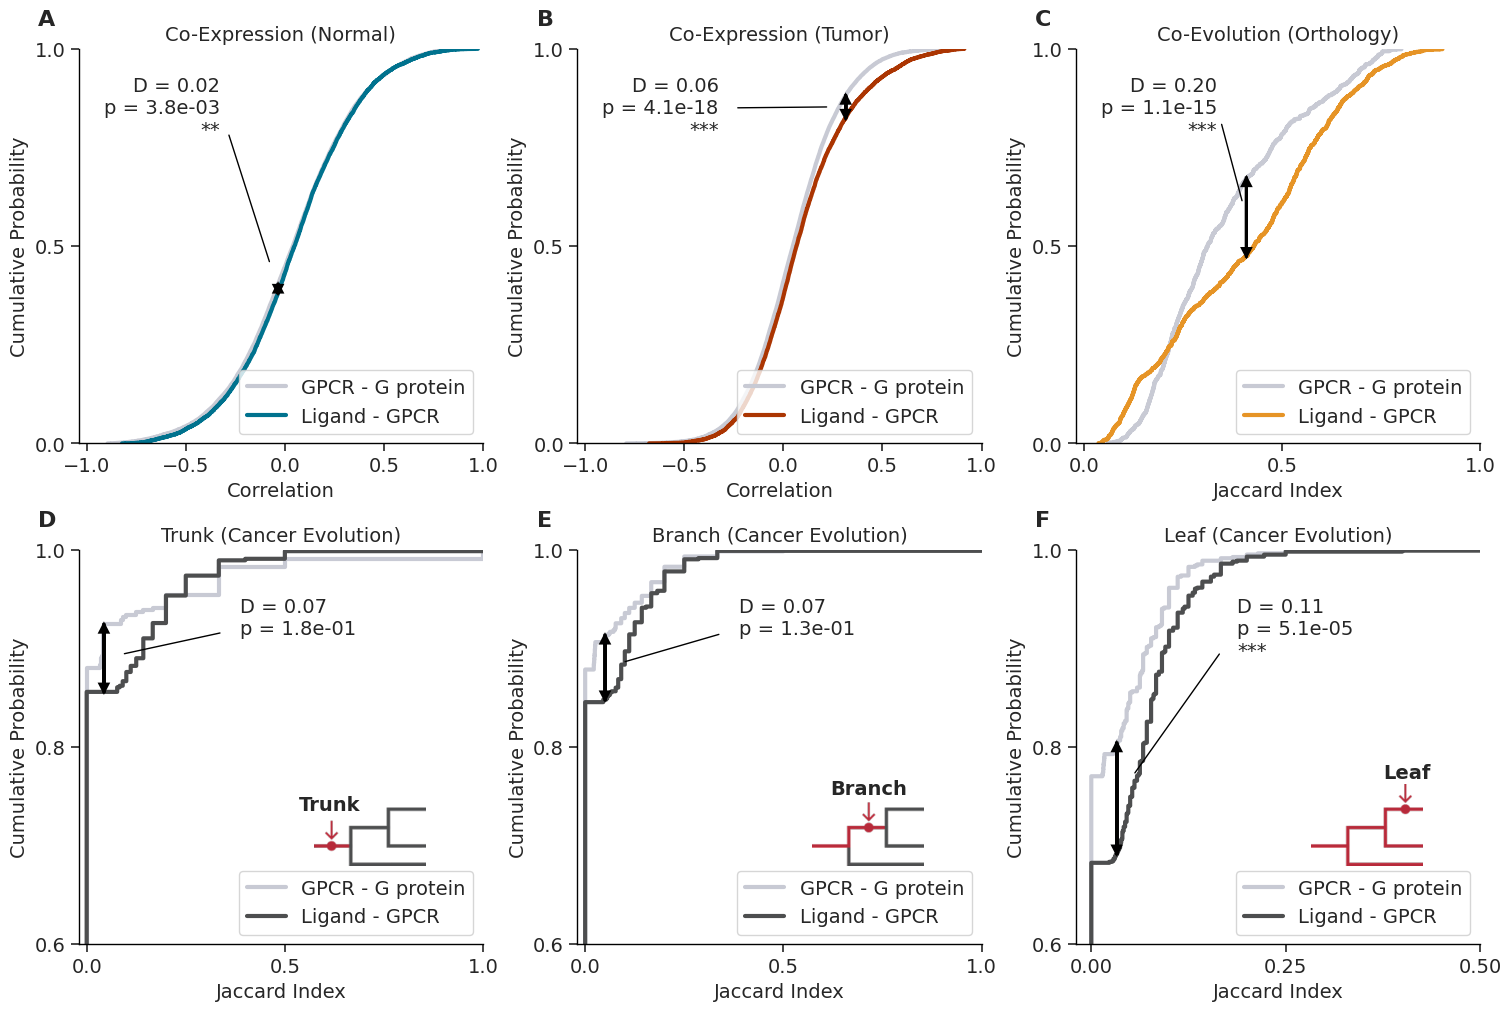

In [52]:
from scipy.stats import ks_2samp
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

fs = 14

# Create figure
fig, axes = plt.subplot_mosaic(
    mosaic="""
    ABC
    DEF
    """,
    figsize=(15, 10),
    constrained_layout=True
)

# Separate the conditions for df and df_jaccard
co_expression_conditions = ['Normal Co-Expression', 'Tumor Co-Expression', 'Coevolution']
jaccard_conditions = ['Trunk', 'Branch', 'Private']

ks_stats = []
p_vals = []

# Run KS test for co-expression conditions using df
for condition in co_expression_conditions:
    ks_stat, p_value = get_pvals_stats(df, condition)  # df for co-expression
    ks_stats.append(ks_stat)
    p_vals.append(p_value)

# Run KS test for Jaccard conditions using df_jaccard
for condition in jaccard_conditions:
    ks_stat, p_value = get_pvals_stats(df_jaccard, condition)  # df_jaccard for Jaccard indices
    ks_stats.append(ks_stat)
    p_vals.append(p_value)

# Apply FDR correction using false_discovery_control
corrected_pvals = false_discovery_control(p_vals)

# Co-expression plots — use defaults
plot_cdf_with_ks(df, 'Normal Co-Expression', axes['A'], ks_stats[0], corrected_pvals[0], ncolor, lightgray, xlim=(-1.04, 1))
plot_cdf_with_ks(df, 'Tumor Co-Expression', axes['B'], ks_stats[1], corrected_pvals[1], tcolor, lightgray, xlim=(-1.04, 1))
#plot_cdf_with_ks(df, 'Coevolution', axes['C'], ks_stats[2], corrected_pvals[2], orangecolor, lightgray, xlim=(-0.02, 1))
plot_cdf_with_ks(df, 'Coevolution', axes['C'], ks_stats[2], corrected_pvals[2], orangecolor, lightgray, xlim=(-0.02, 1))

# Jaccard plots — customize position and alignment
ylim_jaccard = (0.6, 1)
plot_cdf_with_ks(df_jaccard, 'Trunk'  , axes['D'], ks_stats[3], corrected_pvals[3], graycolor, lightgray, ylim=ylim_jaccard, xlim=(-0.02, 1), text_coords=(0.4, 0.8), text_ha='left')
plot_cdf_with_ks(df_jaccard, 'Branch' , axes['E'], ks_stats[4], corrected_pvals[4], graycolor, lightgray, ylim=ylim_jaccard, xlim=(-0.02, 1), text_coords=(0.4, 0.8), text_ha='left')
plot_cdf_with_ks(df_jaccard, 'Private', axes['F'], ks_stats[5], corrected_pvals[5], graycolor, lightgray, ylim=ylim_jaccard, xlim=(-0.02, 0.5), text_coords=(0.4, 0.8), text_ha='left')

# X-axis labels
axes['A'].set_xlabel('Correlation')
axes['B'].set_xlabel('Correlation')
axes['C'].set_xlabel('Jaccard Index')
axes['D'].set_xlabel('Jaccard Index')
axes['E'].set_xlabel('Jaccard Index')
axes['F'].set_xlabel('Jaccard Index')

# Titles
axes['A'].set_title('Co-Expression (Normal)', fontsize=fs)
axes['B'].set_title('Co-Expression (Tumor)', fontsize=fs)
axes['C'].set_title('Co-Evolution (Orthology)', fontsize=fs)
axes['D'].set_title('Trunk (Cancer Evolution)', fontsize=fs)
axes['E'].set_title('Branch (Cancer Evolution)', fontsize=fs)
axes['F'].set_title('Leaf (Cancer Evolution)', fontsize=fs)

axes['D'].set_xticks([0, 0.5, 1])
axes['E'].set_xticks([0, 0.5, 1])
axes['F'].set_xticks([0, 0.25, 0.5])

axes['D'].set_yticks([0.6, 0.8, 1])
axes['E'].set_yticks([0.6, 0.8, 1])
axes['F'].set_yticks([0.6, 0.8, 1])

icons_path = '/home/lnemati/pathway_crosstalk/data/coev_icons'

# === Icon controls ===
icon_scaling_factor = 0.25  # Adjust size of the icons

# === Add icons to panels D, E, and F ===
icon_files = {
    'D': 'trunk_reverse.png',
    'E': 'branch_reverse.png',
    'F': 'leaf_reverse.png',
}

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

for panel, icon_name in icon_files.items():
    icon_path = os.path.join(icons_path, icon_name)
    if os.path.exists(icon_path):
        # Load and resize icon
        icon = Image.open(icon_path)
        width, height = icon.size
        icon_resized = icon.resize((int(width * icon_scaling_factor), int(height * icon_scaling_factor)))
        icon_array = np.array(icon_resized)

        # Create image box
        imagebox = OffsetImage(icon_array, zoom=0.5, resample=True)

        # Position in axes-relative coordinates (x=0.78, y=0.28 is consistent)
        ab = AnnotationBbox(
            imagebox,
            (0.72, 0.3),           # Position of the icon
            xycoords='axes fraction',
            frameon=False
        )

        axes[panel].add_artist(ab)

        # === Add label text above the icon ===
        label_map = {'D': 'Trunk', 'E': 'Branch', 'F': 'Leaf'}
        offsetx = {'D': -0.1,'E': 0, 'F': 0.1}
        offsety = {'D': -0.04,'E': 0, 'F': 0.04}
        axes[panel].text(
            0.72 + offsetx[panel],
            0.37 + offsety[panel],
            label_map[panel],
            transform=axes[panel].transAxes,
            ha='center',
            va='bottom',
            fontsize=fs,
            fontweight='bold'
        )

for ax in axes.values():
    ax.tick_params(length=6, width=1.2)

# === Add panel letters ===
panel_labels = ['A', 'B', 'C', 'D', 'E', 'F']
for label, ax in zip(panel_labels, axes.values()):
    ax.text(
        -0.1, 1.1,  # Top-left corner in axes coords
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='left'
    )
    

# In the legend replace 'G-Protein' with 'GPCR-Gprotein' and 'Ligand' with 'Ligand-GPCR'
for ax in axes.values():
    handles, labels = ax.get_legend_handles_labels()
    new_labels = []
    for label in labels:
        if label == 'G-Protein':
            new_labels.append('GPCR - G protein')
        elif label == 'Ligand':
            new_labels.append('Ligand - GPCR')
        else:
            new_labels.append(label)
    ax.legend(handles, new_labels, fontsize=fs, loc='lower right')

#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/fig2.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/fig2.svg', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig2/fig2.png', bbox_inches='tight', dpi=300)

plt.show()


In [148]:
# Define the base directory where the search should start
base_dir = '/projects/bioinformatics/DB/Xena/TCGA_GTEX/by_tissue_primary_vs_normal'

# Search for all files named 'ccc.csv' in subdirectories
all_paths = []
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file == 'ccc.csv':
            all_paths.append(os.path.join(root, file))

# Initialize an empty list to hold DataFrames
dfs = []

# Process each file and extract relevant columns
for path in all_paths:
    # Extract the tissue type from the directory structure
    tissue = os.path.basename(os.path.dirname(os.path.dirname(path)))  # Parent folder of 'interactions'
    
    # Read the CSV file and extract required columns
    smdf = pd.read_csv(path, index_col='interaction', usecols=['interaction', 'same_module'])
    smdf.rename(columns={'same_module': tissue}, inplace=True)
    dfs.append(smdf)

# Combine all DataFrames along the column axis
same_module = pd.concat(dfs, axis=1)

In [149]:
tissues_df = pd.read_csv('/home/lnemati/pathway_crosstalk/data/tissues.csv', index_col='subtissue')
tissues_df = tissues_df[tissues_df.index != 'testis']

In [150]:
same_module_subtissues = same_module.T
same_module_subtissues.index.name = 'subtissue'

In [151]:
same_module_subtissues.insert(0, 'tissue', tissues_df.loc[same_module_subtissues.index, 'tissue'])
same_module_subtissues.insert(1, 'condition', tissues_df.loc[same_module_subtissues.index, 'condition'])

In [152]:
#same_module_subtissues.to_csv('/home/lnemati/pathway_crosstalk/results/interactions_network/same_module_interactions_all_subtissues.csv')

In [153]:
# Move from subtissues to tissue by averaging
same_module_tissues = same_module_subtissues.groupby(['tissue', 'condition']).mean()

In [154]:
t_tissues = same_module_tissues.reset_index().condition.value_counts()['tumor']
n_tissues = same_module_tissues.reset_index().condition.value_counts()['normal']

In [155]:
tfrac = same_module_tissues.query('condition == "tumor"').mean()
tfrac.name = 'tumor_fraction'
nfrac = same_module_tissues.query('condition == "normal"').mean()
nfrac.name = 'normal_fraction'

In [156]:
same_module_fraction = tfrac.to_frame().join(nfrac)
same_module_fraction = same_module_fraction.loc[same_module_fraction.eval('normal_fraction - tumor_fraction').sort_values().index]
#same_module_fraction.to_csv('/home/lnemati/pathway_crosstalk/results/interactions_network/same_module_interactions_aggregate_tissues.csv')

In [159]:
same_module_fraction.query('tumor_fraction > 0 and normal_fraction == 0')

,tumor_fraction,normal_fraction
interaction,,
CXCL10_CXCR3,0.559524,0.0
CXCL11_CXCR3,0.547619,0.0
CXCL11_DPP4,0.303571,0.0
CD80_CTLA4,0.285714,0.0
WNT2_FRZB,0.285714,0.0
...,...,...
ADM_CALCR,0.011905,0.0
APP_FPR2,0.011905,0.0
DDC_HTR1F,0.011905,0.0


In [160]:
same_module_fraction.query('tumor_fraction == 0 and normal_fraction > 0')

,tumor_fraction,normal_fraction
interaction,,
GLS+SLC17A8_GRM8,0.0,0.002959
GLS+SLC17A6_GRIK2+GRIK5,0.0,0.002959
DKK1_KREMEN2+LRP6,0.0,0.002959
GLS+SLC1A2_GRIN1+GRIN2A,0.0,0.002959
NRG3_ERBB2+ERBB4,0.0,0.002959
...,...,...
WNT6_FZD2+LRP6,0.0,0.301282
VIP_ADCYAP1R1,0.0,0.307199
WNT6_SFRP2,0.0,0.332840


In [161]:
same_module_fraction.query('tumor_fraction > 0 and normal_fraction > 0')

,tumor_fraction,normal_fraction
interaction,,
CSF1_CSF1R,0.773810,0.121795
CXCL9_CXCR3,0.666667,0.076923
CCL3_CCR1,0.654762,0.092702
HLA-DQA2_CD4,0.636905,0.089744
CD86_CD28,0.654762,0.108974
...,...,...
CEL_RORC,0.125000,0.397436
WNT6_SFRP4,0.071429,0.349112
NTF3_NTRK3,0.047619,0.326430


In [164]:
corr_table = pd.read_csv('/home/lnemati/pathway_crosstalk/results/supplementary/gene_scores.csv', index_col=0)

In [167]:
len(corr_table.dropna())

32

In [171]:
len(corr_table.normal_corr.dropna()) + len(corr_table.tumor_corr.dropna())

110

In [182]:
corr_table.query('type == "ligand" and tumor_p < 0.05 and tumor_corr > 0').shape

(24, 6)

In [187]:
corr_table.query('type == "ligand" and tumor_p < 0.05 and tumor_corr > 0').dropna().shape

(14, 6)

# Immunotherapy Prediction

In [188]:
## Read the results
cohorts_dir = '/home/lnemati/pathway_crosstalk/results/immunotherapy/features_sets/tissues'

dfs = []

for cohort in os.listdir(cohorts_dir):
    path = os.path.join(cohorts_dir, cohort, 'metrics')
    for file in os.listdir(path):
        metricsdf = pd.read_csv(os.path.join(path, file))
        metricsdf.columns = ['type'] + list(metricsdf.columns[1:])
        metricsdf['cohort'] = cohort
        
        probs_path = os.path.join(cohorts_dir, cohort, 'prediction_probabilities')
        probs = pd.read_csv(os.path.join(probs_path, 'whole_transcriptome.csv'), index_col=0)
        metricsdf['n_patients'] = probs.shape[1]
        
        dfs.append(metricsdf)
        
metricsdf = pd.concat(dfs, ignore_index=True)

In [193]:
metricsdf

,type,auroc,auprc,cohort,n_patients
0,all_cliques,0.696257,0.506933,full_dataset,1246
1,tls-melanoma,0.640344,0.426425,full_dataset,1246
2,mdsc_pca,0.652477,0.440913,full_dataset,1246
3,all_ccis,0.633006,0.425681,full_dataset,1246
4,ifng,0.669227,0.447924,full_dataset,1246
...,...,...,...,...,...
121,t_cell_dysfunction_pca,0.655806,0.383392,stomach,78
122,tam_m2_pca,0.501253,0.273765,stomach,78
123,tls,0.735171,0.508792,stomach,78
124,whole_transcriptome,0.454470,0.277409,stomach,78


In [199]:
metricsdf.groupby('type')['auroc'].mean().sort_values()[::-1]

type
all_cliques               0.678515
tls                       0.659808
t_cell-inflamed_gep       0.623640
cd8                       0.618567
caf_pca                   0.604786
all_ccis                  0.590638
ifng                      0.580441
tls-melanoma              0.555207
t_cell_dysfunction_pca    0.552864
t_cell_exclusion_pca      0.552677
mdsc_pca                  0.552431
tam_m2_pca                0.539827
whole_transcriptome       0.537741
cd274                     0.524558
Name: auroc, dtype: float64

In [197]:
metricsdf.query('cohort != "full_dataset"').groupby('type')['auprc'].mean().sort_values()[::-1]

type
all_cliques               0.471103
tls                       0.436425
t_cell-inflamed_gep       0.408703
caf_pca                   0.392350
cd8                       0.389526
ifng                      0.384080
all_ccis                  0.367196
mdsc_pca                  0.336486
whole_transcriptome       0.335043
t_cell_dysfunction_pca    0.325331
t_cell_exclusion_pca      0.322436
tam_m2_pca                0.311894
tls-melanoma              0.308607
cd274                     0.307679
Name: auprc, dtype: float64

In [200]:
metricsdf.groupby('type')['auprc'].mean().sort_values()[::-1]

type
all_cliques               0.475084
tls                       0.433277
t_cell-inflamed_gep       0.416799
caf_pca                   0.400883
cd8                       0.392398
ifng                      0.391174
all_ccis                  0.373694
mdsc_pca                  0.348089
whole_transcriptome       0.347505
t_cell_dysfunction_pca    0.340589
t_cell_exclusion_pca      0.335340
tam_m2_pca                0.326527
tls-melanoma              0.321698
cd274                     0.318774
Name: auprc, dtype: float64